# Example 9: Ephemeris and Almanac Fitting

Broadcasting a satellite's full numerically propagated trajectory is impractical:
GNSS-style navigation messages instead broadcast a compact **ephemeris** (a
short-validity, high-precision orbit model, refreshed often) or **almanac** (a
long-validity, coarse orbit model, refreshed rarely) fit to the true trajectory.
Both are a trade-off between broadcast **data size** (number of bits transmitted)
and **fit accuracy** (position/velocity error introduced by compressing the
trajectory into a handful of coefficients).

This example uses two new LuPNT application classes to explore that trade-off for
a lunar orbit:

- `pnt.CartesianEphemeris` -- an osculating two-body Kepler orbit (fit at the
  window midpoint) plus a Chebyshev-polynomial correction on the Cartesian
  position residual, mirroring the "orbital elements + polynomial correction"
  representation used by GNSS broadcast ephemerides (e.g. GPS LNAV).
- `pnt.Almanac` -- a coarse, GNSS-almanac-style model: each classical orbital
  element is a low-order polynomial of time, intended for long validity / small
  broadcast size rather than precision.

`pnt.EphemerisSimulation` then sweeps the fitting-window length for both models,
fits/evaluates each on several windows across a numerically propagated truth
trajectory, and searches (by bisection) the minimum per-parameter broadcast
resolution that keeps the position error under a target precision -- producing
the accuracy-vs-datasize trade-off curves at the end of this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pylupnt as pnt

[00.00][PyLuPNT] Initializing


## Truth trajectory

We reuse the Elliptical Lunar Frozen Orbit (ELFO) from Example 1: classical
orbital elements defined in the Moon-centered **Orbital Plane (OP)** frame,
converted to the **Moon-Centered Inertial (MCI)** frame and propagated with
N-body dynamics (Moon gravity + Earth/Sun third-body).

In [2]:
t0 = pnt.gregorian_to_time(2027, 1, 1, 0, 0, 0)  # [s] TDB

a    = 6541.4e3        # [m]   semi-major axis
e    = 0.6             # [-]   eccentricity
i    = 56.2 * pnt.RAD  # [rad] inclination
raan = 0.0 * pnt.RAD   # [rad] right ascension of the ascending node
w    = 90.0 * pnt.RAD  # [rad] argument of perigee
M0   = 0.0 * pnt.RAD   # [rad] mean anomaly
coe0_op = np.array([a, e, i, raan, w, M0])

period = pnt.get_orbital_period(a, pnt.GM_MOON)  # [s]
print(f"Orbital period: {period / pnt.SECS_HOUR:.2f} hours")

rv0_op  = pnt.classical_to_cart(coe0_op, pnt.GM_MOON)
rv0_mci = pnt.convert_frame(t0, rv0_op, pnt.MOON_OP, pnt.MOON_CI)

dyn = pnt.NBodyDynamics()
dyn.set_frame(pnt.MOON_CI)
dyn.set_units(pnt.SI_UNITS)
dyn.add_body(pnt.create_body(pnt.MOON, 8, 8))
dyn.add_body(pnt.create_body(pnt.EARTH))
dyn.add_body(pnt.create_body(pnt.SUN))
dyn.set_integrator(pnt.IntegratorType.RKF45)
params = pnt.IntegratorParams()
params.reltol = 1e-10
params.abstol = 1e-6
dyn.set_integrator_params(params)
dyn.set_time_step(30.0)  # propagation timestep [s]; see Example 1

dt_s = 60.0
n_days = 1.5
t_s = np.arange(0, n_days * pnt.SECS_DAY + dt_s, dt_s)  # elapsed [s]
tfs = t0 + t_s

rv_truth = dyn.propagate(rv0_mci, tfs)  # [N x 6], MCI frame
print(f"Propagated {n_days} days -- {len(t_s)} samples at {dt_s:.0f} s spacing")

Orbital period: 13.19 hours
Propagated 1.5 days -- 2161 samples at 60 s spacing


## Fitting a single window

Take a 4-hour window near the start of the trajectory and fit both models
directly, then evaluate their fit error against the (denser) truth samples in
that window.

In [3]:
window_min = 240.0
n_window = int(round(window_min * 60.0 / dt_s)) + 1

t_win = t_s[:n_window]
rv_win = rv_truth[:n_window]

cart_opts = pnt.EphemerisFitOptions()
cart_opts.poly_order = 8
cart_opts.use_keplerian_baseline = True
cart_eph = pnt.CartesianEphemeris(cart_opts)

alm_opts = pnt.AlmanacFitOptions()
alm_opts.poly_order = 2
almanac = pnt.Almanac(alm_opts)

params_cart = cart_eph.fit(t_win, rv_win)
params_alm = almanac.fit(t_win, rv_win)

print(f"CartesianEphemeris: {cart_eph.num_params()} params -> {cart_eph.param_names()}")
print(f"Almanac:            {almanac.num_params()} params -> {almanac.param_names()}")

err_cart = cart_eph.eval_error(t_win, rv_win, params_cart)
err_alm = almanac.eval_error(t_win, rv_win, params_alm)

summary = pd.DataFrame(
    {
        "CartesianEphemeris": [err_cart.rms_pos_m[3], err_cart.p95_pos_m[3],
                               err_cart.rms_vel_mps[3], err_cart.p95_vel_mps[3]],
        "Almanac": [err_alm.rms_pos_m[3], err_alm.p95_pos_m[3],
                   err_alm.rms_vel_mps[3], err_alm.p95_vel_mps[3]],
    },
    index=["RMS pos [m]", "95% pos [m]", "RMS vel [m/s]", "95% vel [m/s]"],
)
summary

CartesianEphemeris: 35 params -> ['t_ref', 't_fit', 'a', 'e', 'i', 'raan', 'argp', 'M_ref', 'x_0', 'x_1', 'x_2', 'x_3', 'x_4', 'x_5', 'x_6', 'x_7', 'x_8', 'y_0', 'y_1', 'y_2', 'y_3', 'y_4', 'y_5', 'y_6', 'y_7', 'y_8', 'z_0', 'z_1', 'z_2', 'z_3', 'z_4', 'z_5', 'z_6', 'z_7', 'z_8']
Almanac:            20 params -> ['t_ref', 't_fit', 'a_0', 'a_1', 'a_2', 'e_0', 'e_1', 'e_2', 'i_0', 'i_1', 'i_2', 'raan_0', 'raan_1', 'raan_2', 'argp_0', 'argp_1', 'argp_2', 'M_0', 'M_1', 'M_2']


,CartesianEphemeris,Almanac
RMS pos [m],0.787882,210.387937
95% pos [m],1.331337,304.469655
RMS vel [m/s],0.003980,0.041008
95% vel [m/s],0.005088,0.072139


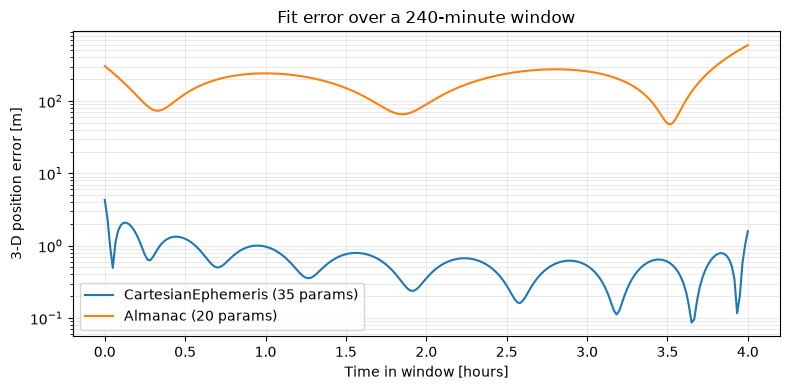

In [4]:
fit_cart = cart_eph.eval(t_win, params_cart)
fit_alm = almanac.eval(t_win, params_alm)

t_hr = (t_win - t_win[0]) / pnt.SECS_HOUR
pos_err_cart = np.linalg.norm(fit_cart[:, :3] - rv_win[:, :3], axis=1)
pos_err_alm = np.linalg.norm(fit_alm[:, :3] - rv_win[:, :3], axis=1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_hr, pos_err_cart, label=f"CartesianEphemeris ({cart_eph.num_params()} params)")
ax.plot(t_hr, pos_err_alm, label=f"Almanac ({almanac.num_params()} params)")
ax.set_xlabel("Time in window [hours]")
ax.set_ylabel("3-D position error [m]")
ax.set_yscale("log")
ax.set_title(f"Fit error over a {window_min:.0f}-minute window")
ax.legend()
ax.grid(True, which="both", lw=0.4, alpha=0.5)
plt.tight_layout()
plt.show()

## Accuracy vs. datasize trade-off

`pnt.EphemerisSimulation` automates the study above across a sweep of fitting-
window lengths: for each window length it samples several windows across the
truth trajectory, fits/evaluates both models on each, and searches (by
bisection) the minimum per-parameter broadcast resolution that keeps the mean
position error under `datasize_precision_m` -- giving a total bit count per
window length for each model.

In [5]:
config = pnt.EphemerisSimulationConfig()
config.start_epoch_utc = "2027-01-01T00:00:00"
config.orbit.a_m = a
config.orbit.ecc = e
config.orbit.inc_rad = i
config.orbit.raan_rad = raan
config.orbit.argp_rad = w
config.orbit.m0_rad = M0
config.orbit.coe_frame = pnt.MOON_OP
config.propagate_frame = pnt.MOON_CI

config.duration_days = 1.5
config.sample_dt_s = 60.0
config.moon_gravity_degree = 8
config.moon_gravity_order = 8
config.include_earth = True
config.include_sun = True

config.fit_window_minutes = [60.0, 120.0, 240.0]
config.num_windows = 4
config.cartesian_poly_order = 6
config.cartesian_use_keplerian_baseline = True
config.almanac_poly_order = 2
config.datasize_precision_m = 0.05

esim = pnt.EphemerisSimulation(config)
esim.setup()
esim.run()

def results_to_df(results, label):
    df = pd.DataFrame(
        {
            "fit_window_min": [r.fit_window_min for r in results],
            "num_params": [r.num_params for r in results],
            "total_bits": [r.total_bits for r in results],
            "pos_rms_m": [r.pos_rms_m for r in results],
            "pos_p95_m": [r.pos_p95_m for r in results],
            "vel_rms_mps": [r.vel_rms_mps for r in results],
            "vel_p95_mps": [r.vel_p95_mps for r in results],
        }
    )
    df["model"] = label
    return df

df_cart = results_to_df(esim.get_cartesian_results(), "CartesianEphemeris")
df_alm = results_to_df(esim.get_almanac_results(), "Almanac")
df = pd.concat([df_cart, df_alm], ignore_index=True)
df


[00.72] Ephemeris datasize/accuracy sweep 100%|██████████| 3/3 [00:01<00:00, 2.1 it/s]


,fit_window_min,num_params,total_bits,pos_rms_m,pos_p95_m,vel_rms_mps,vel_p95_mps,model
0,60.0,29,380,0.035193,0.062773,0.000396,0.000766,CartesianEphemeris
1,120.0,29,417,0.542579,0.954810,0.002999,0.005245,CartesianEphemeris
2,240.0,29,468,6.215197,10.397680,0.012867,0.024195,CartesianEphemeris
3,60.0,20,536,18.642933,33.242884,0.005042,0.008298,Almanac
4,120.0,20,543,97.018368,149.529113,0.017534,0.034251,Almanac
5,240.0,20,541,242.675174,400.420363,0.055679,0.116498,Almanac


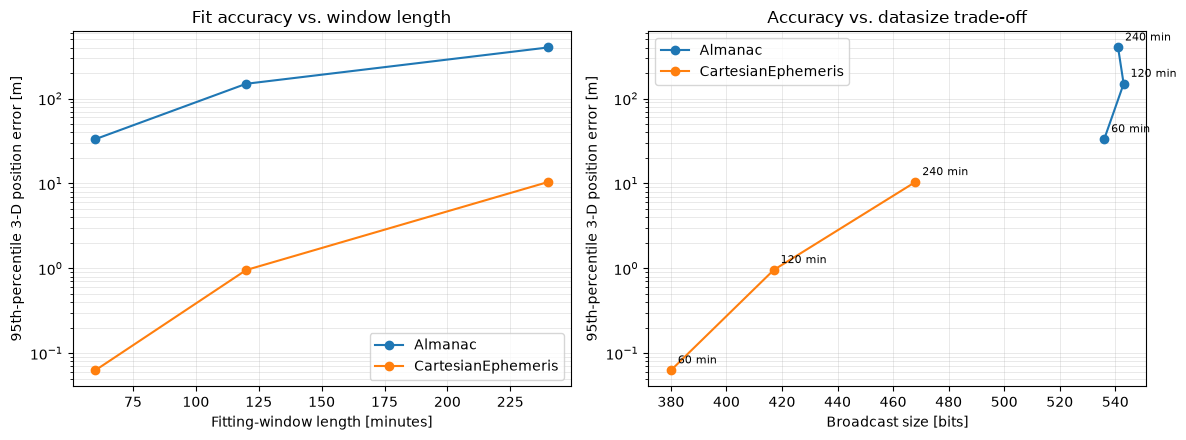

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for label, sub in df.groupby("model"):
    sub = sub.sort_values("fit_window_min")
    axes[0].plot(sub["fit_window_min"], sub["pos_p95_m"], "o-", label=label)
    axes[1].plot(sub["total_bits"], sub["pos_p95_m"], "o-", label=label)
    for _, row in sub.iterrows():
        axes[1].annotate(f"{row.fit_window_min:.0f} min", (row.total_bits, row.pos_p95_m),
                         textcoords="offset points", xytext=(5, 5), fontsize=8)

axes[0].set_xlabel("Fitting-window length [minutes]")
axes[0].set_ylabel("95th-percentile 3-D position error [m]")
axes[0].set_yscale("log")
axes[0].set_title("Fit accuracy vs. window length")
axes[0].legend()
axes[0].grid(True, which="both", lw=0.4, alpha=0.5)

axes[1].set_xlabel("Broadcast size [bits]")
axes[1].set_ylabel("95th-percentile 3-D position error [m]")
axes[1].set_yscale("log")
axes[1].set_title("Accuracy vs. datasize trade-off")
axes[1].legend()
axes[1].grid(True, which="both", lw=0.4, alpha=0.5)

plt.tight_layout()
plt.show()

### Takeaways

- `CartesianEphemeris` is both far more *accurate* and more *bit-efficient* than
  `Almanac` here: its two-body-plus-Chebyshev representation removes the bulk of
  the orbital motion analytically, so the polynomial only has to capture the
  (small, smooth) perturbation residual -- sub-meter accuracy at ~400 bits for a
  1-hour window on this eccentric (e=0.6) lunar orbit.
- `Almanac`'s low-order polynomial tracks each osculating orbital element
  directly with no two-body removal, so it needs orders of magnitude more
  position error to reach the same window length -- and, in this bit-allocation
  model, similar or *more* total bits, since every polynomial coefficient of an
  angular element (i, RAAN, argument of periapsis, mean-anomaly residual) is
  conservatively budgeted the full 2*pi range regardless of its actual
  (typically much smaller) magnitude. A tighter per-coefficient range estimate
  would likely narrow or reverse this gap -- exactly the kind of design
  trade-off study `EphemerisSimulation` is meant to support.
- Both curves illustrate the same broadcast-ephemeris design trade-off used by
  GNSS constellations: a precise, short-validity ephemeris updated often vs. a
  coarse, long-validity almanac updated rarely -- with the "right" choice
  depending on the receiver's accuracy needs and the link's update cadence.